In [1]:
# import system libraries
import logging
import sys, copy
# import scientific libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.signal
from scipy.interpolate import InterpolatedUnivariateSpline as spline
import h5py
import pandas as pd
# import data analysis libraries
from ldc.waveform.lisabeta import FastBHB
import lisabeta.lisa.lisa as lisa
from lisabeta.lisa.lisa import EvaluateTDIFreqseries
import lisabeta.tools.pyspline as pyspline
import lisabeta.lisa.lisatools as lisatools
import lisabeta.tools.pytools as pytools
from ldc.common import tools
from ldc.lisa.noise import AnalyticNoise, get_noise_model
from chainconsumer import Chain, ChainConsumer, make_sample, Truth
import lisaconstants
# import sampler libraries
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import uniform_dist, ProbDistContainer
from ldc.waveform.waveform import HpHc

mpl.rcParams.update(mpl.rcParamsDefault)

Could not import fastgb. Please pip install fastgb


# Set up injection and find noiseless Afull and Efull. Set up Npsd, timing, and frequencies

In [2]:
#imports all dependencies and homebrewed functions
import LISA_TTL_Functions as foc

In [3]:
#set up the injection

pMBHB_ldc = {'EclipticLatitude': -0.30300442294174235,
 'EclipticLongitude': 1.2925183861048521,
 'PolarAngleOfSpin1': 1.2031361791056812,
 'PolarAngleOfSpin2': 2.097303543065685,
 'Spin1': 0.747377,
 'Spin2': 0.8388,
 'Mass1': 1323277.47932, #original 1323277.47932
 'Mass2': 612485.5060299999, #original 612485.5060299999
 'CoalescenceTime': 11526944.921879262,
 'PhaseAtCoalescence': 1.2201968860015653,
 'InitialPolarAngleL': 2.6919824500032945,
 'InitialAzimuthalAngleL': 1.808398497592109,
 'Redshift': 1.73941,
 'Distance': 13470.983559 , #13470.983559 original
 'ObservationDuration': 31558149.763545603,
 'Cadence': 3.0}

snr = 22295 for distance 1347.983559 \
snr = 223 for distance 134700 \
snr = 12021 for distance 2500 \
snr = 2230 for distance 13470 \
snr = 7026 for mass x10 distance 2500 \
snr = 1303 for mass x10 distance 13470 \
snr = 130 for mass x10 distance 134700 \
snr = 2096 for mass x.1 distance 2500 \
snr = 389 for mass x0.1 distance 13470 \
snr = 38 for mass x0.1 distance 134700

In [4]:
snr_unrounded = foc.snr_check(pMBHB_ldc)
snr = int(snr_unrounded)
difference = 'All_modes_interpolated'
print(snr)

2230.9845934810273
2230


In [5]:
#establish t_min, max, separation and number of samples
t_min = 0
t_max = pMBHB_ldc["CoalescenceTime"]+1000
dt = 0.25
df = 1/t_max

t = np.arange(t_min, t_max, dt)

In [6]:
#set up the injection in lisabeta terms
FBH = FastBHB("MBHB", T=t_max, delta_t=dt, approx="IMRPhenomHM")

pMBHB = FBH.rename_as_lisabeta(pMBHB_ldc)

print(pMBHB.keys())

dict_keys(['beta', 'lambda', 'chi1', 'chi2', 'm1', 'm2', 'Deltat', 'phi', 'dist', 'psi', 'inc'])


In [7]:
#background settings
waveform_params_smbh = {
    "minf": 1e-5,
    "maxf": 1,
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "tmax": 1.0,
    "TDI": "TDI2AET",
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": False,
    "modes": None,
    # Waveform approximant and set of harmonics to use 
    "approximant": "IMRPhenomHM"
}

In [8]:
'''
#generate signal
tdisignal = lisa.GenerateLISATDISignal_SMBH(pMBHB, **waveform_params_smbh)
tdi = tdisignal['tdi']
mbh_lb = tdi[(2,2)]
#generate frequency grid
freq = mbh_lb['freq']
freq = freq[freq>0]
#generate data
modesf  = tdisignal['tdi']['modes']
A_full = 0
E_full = 0
for i in range(0,len(modesf)):
    mbh_lb = tdi[modesf[i]]

    Af_partial = np.conjugate((mbh_lb['amp_real_chan1'] + 1.j*mbh_lb['amp_imag_chan1'])*np.exp(1j* mbh_lb['phase']))
    Ef_partial = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2'])*np.exp(1j* mbh_lb['phase']))

    #plt.loglog(freq, np.abs(Af_partial)**2,'.', markersize = .5, label = str(modesf[i]))
    #plt.legend()

    A_full = A_full + Af_partial
    E_full = E_full + Ef_partial
#A_full = np.conjugate((mbh_lb['amp_real_chan1'] + 1.j*mbh_lb['amp_imag_chan1'])*np.exp(1j* mbh_lb['phase']))
#E_full = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2'])*np.exp(1j* mbh_lb['phase']))
#generate noise PSD

Nmodel = AnalyticNoise(freq, model="SciRDv1") # or whatever version you prefer. In the previous notebook we used "sangria"
Npsd = Nmodel.psd(option='A', tdi2=True)
'''



'\n#generate signal\ntdisignal = lisa.GenerateLISATDISignal_SMBH(pMBHB, **waveform_params_smbh)\ntdi = tdisignal[\'tdi\']\nmbh_lb = tdi[(2,2)]\n#generate frequency grid\nfreq = mbh_lb[\'freq\']\nfreq = freq[freq>0]\n#generate data\nmodesf  = tdisignal[\'tdi\'][\'modes\']\nA_full = 0\nE_full = 0\nfor i in range(0,len(modesf)):\n    mbh_lb = tdi[modesf[i]]\n\n    Af_partial = np.conjugate((mbh_lb[\'amp_real_chan1\'] + 1.j*mbh_lb[\'amp_imag_chan1\'])*np.exp(1j* mbh_lb[\'phase\']))\n    Ef_partial = np.conjugate((mbh_lb[\'amp_real_chan2\'] + 1.j*mbh_lb[\'amp_imag_chan2\'])*np.exp(1j* mbh_lb[\'phase\']))\n\n    #plt.loglog(freq, np.abs(Af_partial)**2,\'.\', markersize = .5, label = str(modesf[i]))\n    #plt.legend()\n\n    A_full = A_full + Af_partial\n    E_full = E_full + Ef_partial\n#A_full = np.conjugate((mbh_lb[\'amp_real_chan1\'] + 1.j*mbh_lb[\'amp_imag_chan1\'])*np.exp(1j* mbh_lb[\'phase\']))\n#E_full = np.conjugate((mbh_lb[\'amp_real_chan2\'] + 1.j*mbh_lb[\'amp_imag_chan2\'])*np.exp

# generate splined afull

In [9]:
#generate interpolated signal
tdisignal = lisa.GenerateLISATDISignal_SMBH(pMBHB, **waveform_params_smbh)
tdi = tdisignal['tdi']
mbh_lb_2 = tdi[(2,2)]

In [10]:
#Fvec for interpolation
fmin = mbh_lb_2['freq'][0]
fmax = mbh_lb_2['freq'][-1]
ndata = int(t_max/dt)
df = 1/t_max

# Get the full frequencies
if (ndata % 2)==0:              # Get the number of requencies
    nfft = int((ndata/2)+1)
else:
    nfft = int((ndata+1)/2)

F = df*nfft                 # make the positive frequency vector
fvec = np.arange(0, F, df)

# Get the frequencies of interest
f_inds = np.where(np.logical_and(fvec >= fmin, fvec < fmax))
fvec = fvec[f_inds]
fvec = fvec[fvec>0]
print(fvec)

[4.86643546e-05 4.87511004e-05 4.88378461e-05 ... 2.09760718e-02
 2.09761585e-02 2.09762453e-02]


In [11]:
#downsample fvec so it cant get too small
stride = 80 # 3016 bins

if len(fvec) != 3016:
    fvec_coarse = fvec[::stride]  
    print(len(fvec_coarse))
    fvec = np.ascontiguousarray(fvec_coarse)
else:
    pass

3016


# construct splined afull on fvec grid

In [12]:
#generate data
modesf  = tdisignal['tdi']['modes']

print(modesf)
A_full = np.zeros(len(fvec), dtype=complex)
E_full = np.zeros(len(fvec), dtype=complex)

for i in range(len(modesf)):
    mbh_lb = tdi[modesf[i]]

    mask = (fvec >= mbh_lb['freq'].min()) & (fvec <= mbh_lb['freq'].max())
    
    #phase
    splPh = spline(mbh_lb['freq'], mbh_lb['phase'], ext='raise')
    #A
    splAr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan1'])
    splAi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan1'])
    #E
    splEr = spline(mbh_lb['freq'], mbh_lb['amp_real_chan2'])
    splEi = spline(mbh_lb['freq'], mbh_lb['amp_imag_chan2'])

    A_full[mask] += np.conjugate((splAr(fvec[mask]) + 1.j*splAi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))
    E_full[mask] += np.conjugate((splEr(fvec[mask]) + 1.j*splEi(fvec[mask])) * np.exp(1j*splPh(fvec[mask])))

Nmodel = AnalyticNoise(fvec, model="SciRDv1") # or whatever version you prefer. In the previous notebook we used "sangria"
Npsd = Nmodel.psd(option='A', tdi2=True)

# constructing signal at each Fouriner freq.

[(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)]


In [13]:
Afull = A_full
Efull = E_full

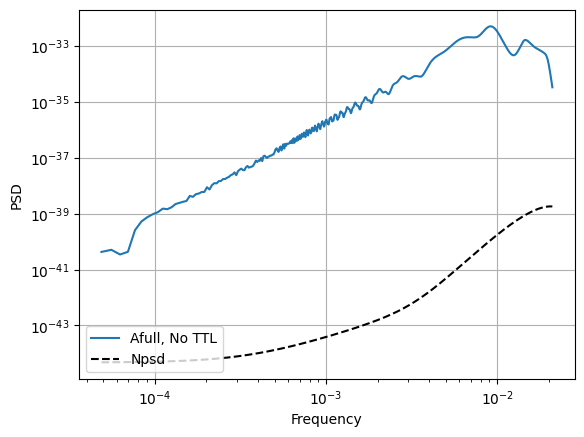

In [14]:
fig, ax = plt.subplots()
ax.loglog(fvec, np.abs(Afull)**2, label = 'Afull, No TTL')
ax.loglog(fvec, Npsd, '--', color = 'k', label = 'Npsd')
ax.set_xlabel('Frequency')
ax.set_ylabel('PSD')
ax.legend(loc = 'lower left')
ax.grid()

# Check generation with custom grid fvec

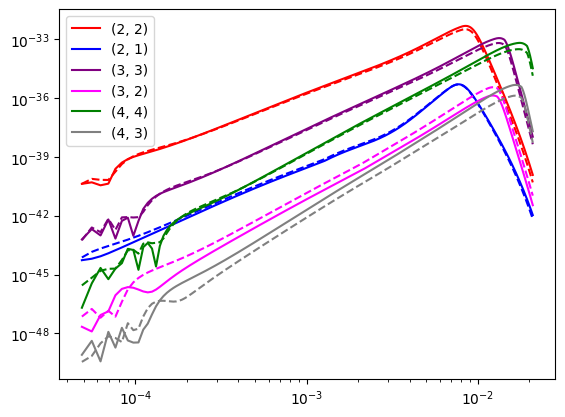

In [15]:

tdisignal_check = lisa.GenerateLISATDISignal_SMBH(pMBHB, gridfreq=fvec, 
                                                  scale_freq_hm=False,  #REQUIRED
                                                  **waveform_params_smbh)
modes = tdisignal['tdi']['modes']
colors = ['red', 'blue', 'purple', 'magenta', 'green', 'gray']


A_trial = np.zeros(len(fvec), dtype=complex)
E_trial = np.zeros(len(fvec), dtype=complex)

for i in range(len(modes)):
    mbh_lb = tdisignal_check['tdi'][modes[i]]

    A_partial = np.conjugate((mbh_lb['amp_real_chan1'] + 1.j*mbh_lb['amp_imag_chan1']) * np.exp(1j*mbh_lb['phase']))
    E_partial = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2']) * np.exp(1j*mbh_lb['phase']))

    plt.loglog(fvec, np.abs(A_partial)**2, label = str(modesf[i]), color = colors[i])
    plt.loglog(fvec, np.abs(E_partial)**2, '--', color = colors[i])
    plt.legend()

    A_trial += A_partial
    E_trial += E_partial


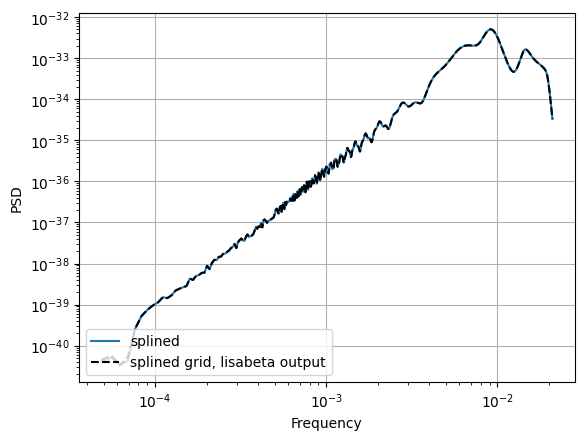

In [16]:
fig, ax = plt.subplots()
ax.loglog(fvec, np.abs(Afull)**2, label = 'splined')
ax.loglog(fvec, np.abs(A_trial)**2,'--', color = 'k', label = 'splined grid, lisabeta output')

ax.set_xlabel('Frequency')
ax.set_ylabel('PSD')
ax.legend(loc = 'lower left')
ax.grid()

# Set up the MCMC: array for trials, likelihood, priors, initial condition, temps, walkers, samples, etc

In [17]:
#now we set things up for mcmc
#solving for chirpmass and ratio
m1 = pMBHB['m1']
m2 = pMBHB['m2']
q = m1/m2
Mc = (m1+m2)*(q/(1+q)**2)**0.6

src0 = pMBHB.copy()
#src0.pop("m1"); src0.pop("m2")
del src0['m2']
del src0['m1']
src0["Mchirp"] = Mc
src0["q"] = q
#src0['psi'] += np.pi
#src0['phi'] -= np.pi

keys = src0.keys()

#create the array to be altered in likelihood
src = copy.deepcopy(src0)

In [18]:
print(pMBHB.keys())
print(src.keys())

dict_keys(['beta', 'lambda', 'chi1', 'chi2', 'm1', 'm2', 'Deltat', 'phi', 'dist', 'psi', 'inc'])
dict_keys(['beta', 'lambda', 'chi1', 'chi2', 'Deltat', 'phi', 'dist', 'psi', 'inc', 'Mchirp', 'q'])


In [ ]:
#claude slightly edit mask
def likelihood(params):

    src = {k: v for k, v in zip(keys, params)}
    m2 = Mc * (1+q)**0.2 / q**0.6
    m1 = q * m2
    src['m1'] = m1
    src['m2'] = m2

    tdisignal_likelihood = lisa.GenerateLISATDISignal_SMBH(src, 
                                                gridfreq=fvec,
                                                scale_freq_hm=False,
                                                 **waveform_params_smbh)
    
    modes = tdisignal_likelihood['tdi']['modes']

    A_trial = np.zeros(len(fvec), dtype=complex)
    E_trial = np.zeros(len(fvec), dtype=complex)

    for i in range(len(modes)):
        mbh_lb = tdisignal_likelihood['tdi'][modes[i]]

        A_partial = np.conjugate((mbh_lb['amp_real_chan1'] + 1.j*mbh_lb['amp_imag_chan1']) * np.exp(1j*mbh_lb['phase']))
        E_partial = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2']) * np.exp(1j*mbh_lb['phase']))
        
        A_trial += A_partial
        E_trial += E_partial

    SN_m = 4.0*df*np.sum(np.real(Afull*np.conjugate(A_trial))/Npsd) + 4.0*df*np.sum(np.real(Efull*np.conjugate(E_trial))/Npsd)
    XX = 4.0*df*np.sum(np.abs(A_trial)**2/Npsd) + 4.0*df*np.sum(np.abs(E_trial)**2/Npsd)

    likelihoodc = SN_m - 0.5*XX
    return likelihoodc #, A_trial

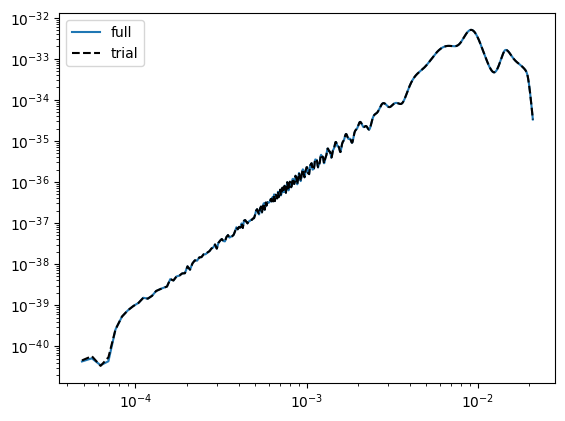

In [27]:
lik, atrial = likelihood(list(src0.values()))
plt.loglog(fvec, np.abs(A_full)**2, label = 'full') 
plt.loglog(fvec, np.abs(A_trial)**2, '--', color = 'k', label = 'trial')
plt.legend()

In [ ]:

#More checks
scream = src0.copy()
m2 = Mc * (1+q)**0.2 / q**0.6
m1 = q * m2
scream['m1'] = m1
scream['m2'] = m2

tdisignal_check = lisa.GenerateLISATDISignal_SMBH(scream, gridfreq=fvec, 
                                                  scale_freq_hm=False,  #REQUIRED
                                                  **waveform_params_smbh)
modes = tdisignal_check['tdi']['modes']

A_trial = np.zeros(len(fvec), dtype=complex)
E_trial = np.zeros(len(fvec), dtype=complex)

for i in range(len(modes)):
    mbh_lb = tdisignal_check['tdi'][modes[i]]

    A_partial = np.conjugate((mbh_lb['amp_real_chan1'] + 1.j*mbh_lb['amp_imag_chan1']) * np.exp(1j*mbh_lb['phase']))
    E_partial = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2']) * np.exp(1j*mbh_lb['phase']))

    A_trial += A_partial
    E_trial += E_partial

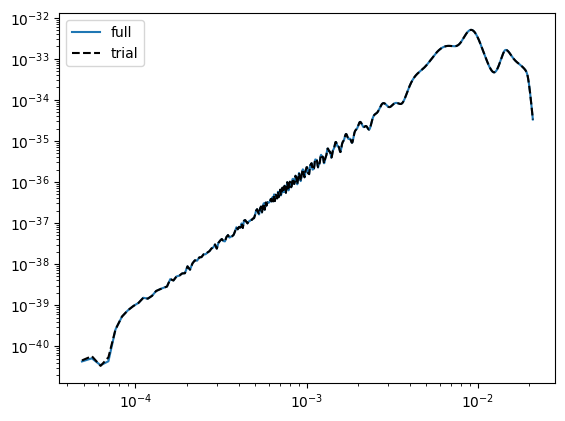

In [ ]:
plt.loglog(fvec, np.abs(A_full)**2, label = 'full') 
plt.loglog(fvec, np.abs(A_trial)**2, '--', color = 'k', label = 'trial')
plt.legend()

In [64]:
day_sec = 86400

priors = {"mbh": ProbDistContainer({
    0: uniform_dist(-np.pi/2, np.pi/2), #lambda
    1: uniform_dist(-np.pi, np.pi), #beta
    2: uniform_dist(-1, 1), #chi1
    3: uniform_dist(-1, 1), #chi2
    4: uniform_dist(100*day_sec, 175*day_sec), #deltat
    5: uniform_dist(-np.pi, np.pi), #phi
    6: uniform_dist(500.0, 2000000.0), #dist 
    7: uniform_dist(0., np.pi), #psi
    8: uniform_dist(0., np.pi), #inc
    9: uniform_dist(1e4, 1e7), #mchirp 
    10: uniform_dist(1, 10), #q
})}

ndims = {"mbh": 11}
df = fvec[1]-fvec[0]

In [65]:
ntemps = 5
nwalkers = 22
nsamples = 2500
ndims = {"mbh": 11}

In [66]:
theta0 = np.array([[np.hstack(
          (np.random.randn(ndims["mbh"]) * 1e-8) + np.array(list(src0.values())))
          for i in range(nwalkers)]
          for _ in range(ntemps)])
#keys = src0.keys()

start_state = State({"mbh": theta0})

In [67]:

sampler = EnsembleSampler(
    nwalkers,
    ndims,
    likelihood,
    priors,
    args=(),
    branch_names=["mbh"],
    tempering_kwargs=dict(ntemps=ntemps, Tmax=np.inf),
    nleaves_max=dict(mbh=1),
    #pool=pool,
)

# Run the MCMC

In [68]:
sampler.run_mcmc(start_state, nsamples, progress=True, store = True)

  0%|          | 12/2500 [00:40<2:26:44,  3.54s/it]Traceback (most recent call last):
  File "/Users/corinnekomlodi/Desktop/Robbie_UV/.venv/lib/python3.11/site-packages/eryn/ensemble.py", line 1644, in __call__
    out = self.f(*args_in, **kwargs_in)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/mb/k18m72t149vc_bk4zdmscvxr0000gn/T/ipykernel_18583/1446268894.py", line 17, in likelihood
    E_trial = np.conjugate((mbh_lb['amp_real_chan2'] + 1.j*mbh_lb['amp_imag_chan2']) * np.exp(1j*mbh_lb['phase']))
                                                                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
  0%|          | 12/2500 [00:43<2:31:52,  3.66s/it]

eryn: Exception while calling your likelihood function:
  args added: [array([-3.03002851e-01,  1.29251850e+00,  2.68632361e-01, -4.21511329e-01,
        1.15269449e+07, -1.92139610e+00,  1.34709836e+04,  1.29122260e+00,
        2.25179024e+00,  7.72462857e+05,  2.16050444e+00])]
  args: ()
  kwargs added: {}
  kwargs: {}
  exception:


KeyboardInterrupt: 

# Plot corner and walkers

In [48]:
#define truths
keys = src0.keys()
labels = list(keys)

inj=np.array(list(src0.values()))

truths = inj.flatten()
labels_final = labels

In [49]:
truth = pd.DataFrame(data = truths , columns = ['truths'])
csv_filename_truth = str(snr) + difference + "_snr_truth.csv"
truth.to_csv(csv_filename_truth, index=False)

In [52]:
burn = 0

Parameter beta in chain noiseless is not constrained
Parameter chi1 in chain noiseless is not constrained
Parameter chi2 in chain noiseless is not constrained
Parameter phi in chain noiseless is not constrained
Parameter psi in chain noiseless is not constrained


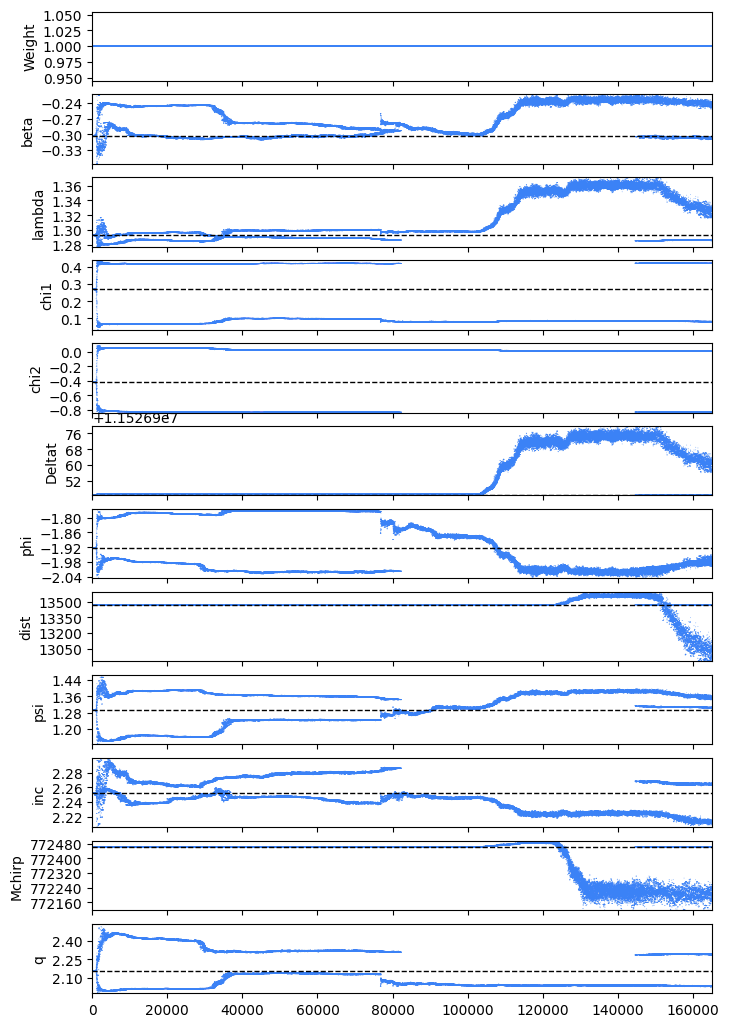

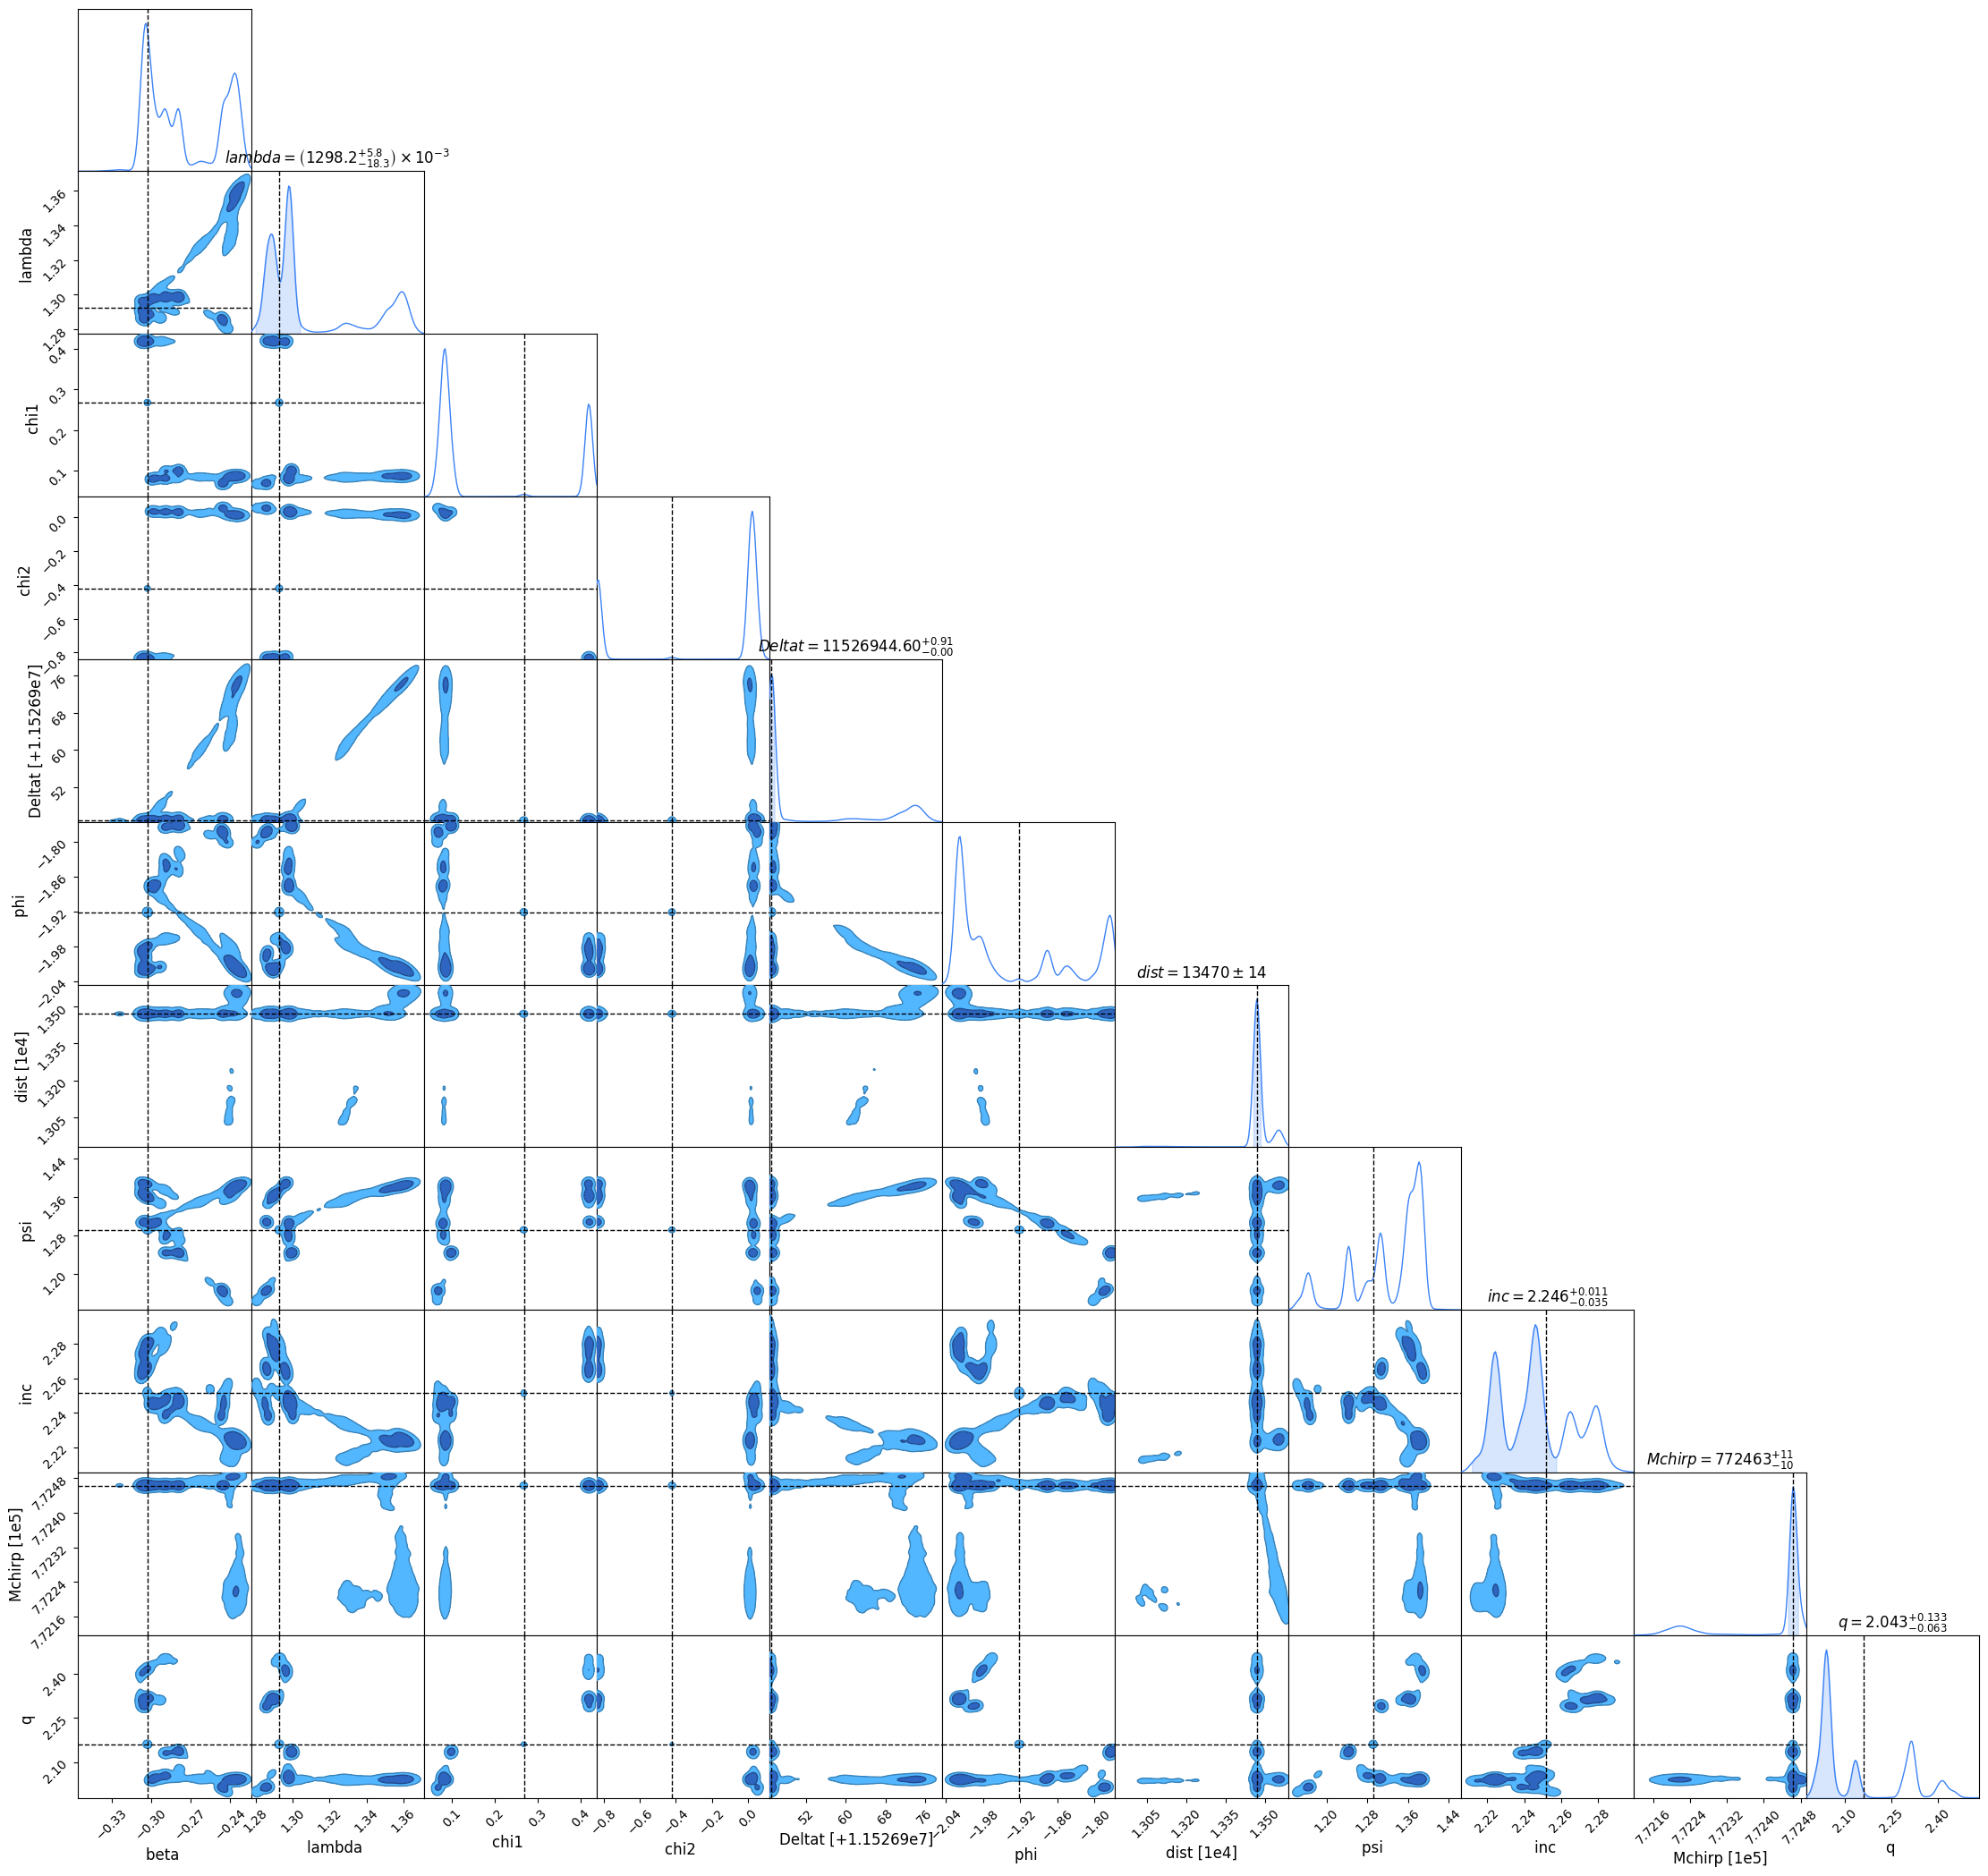

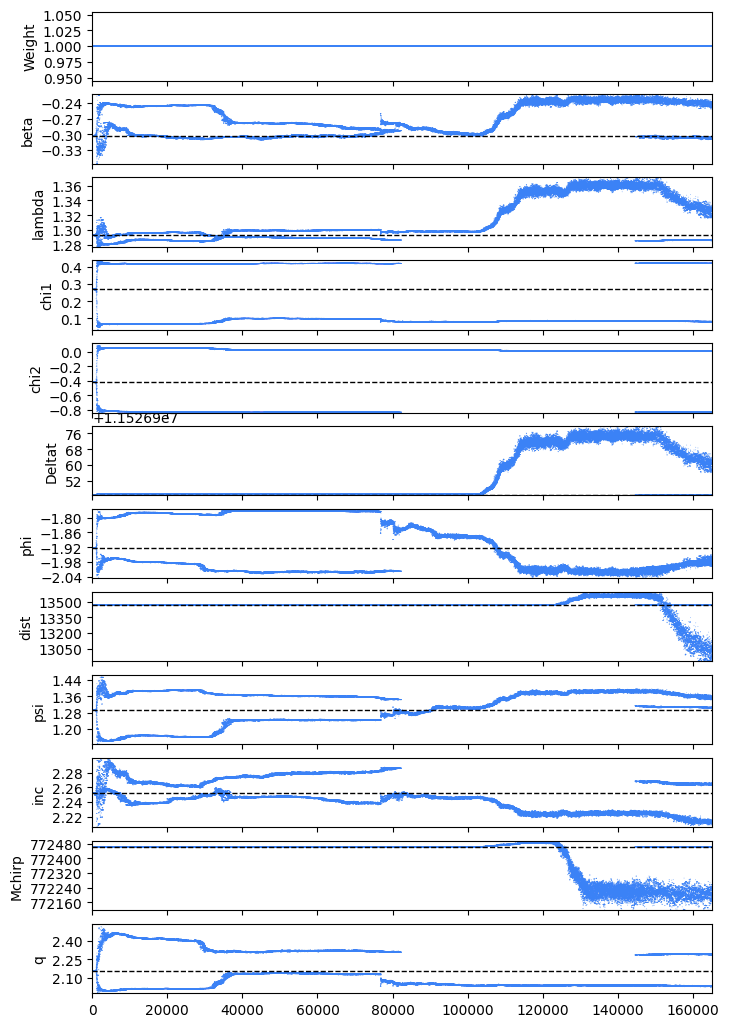

In [53]:
c = ChainConsumer()

samples_2ch = sampler.get_chain()["mbh"][:, 0].reshape(-1, 11)

dfs_2chnls = pd.DataFrame(samples_2ch[burn:, :], columns = keys)

c.add_chain(Chain(samples=dfs_2chnls, name="noiseless", color="blue"))
c.add_truth(Truth(location={k:v for (k,v) in zip(labels_final,truths)}))

c.plotter.plot()
c.plotter.plot_walks()

In [54]:
csv_filename_0mm = "0mm_"+ str(snr)+ difference + "_snr_chains.csv"
dfs_2chnls.to_csv(csv_filename_0mm, index=False)
print(f"Chain data saved to {csv_filename_0mm}")

Chain data saved to 0mm_2230All_modes_interpolated_snr_chains.csv
